# Proposed approach:
- Compute hit rate from IAGOS data by aggregating IAGOS measurements onto the forecast grid. Forecast grid cells are flagged if at least one IAGOS measurement indicates that the grid cell contains a PCR. The hit rate is defined as the fraction of flagged grid cells where the forecast predicts persistent contrail formation.
- Penalize the forecast for overprediction by computing the total flight distance through forecast PCRs. This is computed by aggregating flight distance from a (hopefully) comprehensive ADSB dataset within forecast grid cells and summing aggregated flight distances over all grid cells where the forecast predicts persistent contrail formation.

Some implementation details:
- This approach requires defining boundaries for forecast grid cells. Our forecast has 0.25 degree horizontal resolution, 1 flight level vertical resolution, and hourly time resolution, so I'm defining points as points within +/- 0.125 degree, +/- 500 ft, and +/- 30 minutes from points where our forecast provides predictons.
- Aggregated IAGOS and ADSB data is very sparse at the granularity of our forecast (1 flight level and one time), so I'm trying to minimize processed data volume by saving results in parquet values with zeros dropped. The volume even of raw IAGOS data is tiny, so I don't anticipate any issues pulling aggregated IAGOS data to disk. Aggregated ADSB data requires about ~500 MB per flight level and time, though, which is probably too much to ask users to pull without some additional processing.

In [1]:
import datetime

import cartopy.crs as ccrs
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np

from pipelines.preprocess_adsb import preprocess_adsb
from pipelines.preprocess_contrails_org import preprocess_forecast
from pipelines.preprocess_iagos import preprocess_iagos
from pipelines.contrails_org_iagos import open_adsb, open_forecast, open_iagos, apply_horizontal_buffer, calculate_pcr_area, calculate_flight_distance

In [3]:
time = datetime.datetime(2024, 6, 1, 10)
flight_level = 350

# Contrails.org forecasts

I'm pulling EF values from the API and flagging grid cells where EF is nonzero (not necessarily positive) as predicted PCRs. This is all something an external user could reproduce, provided they have access to our API.

In [4]:
preprocess_forecast(time, flight_level)

In [5]:
forecast = open_forecast(time, flight_level)

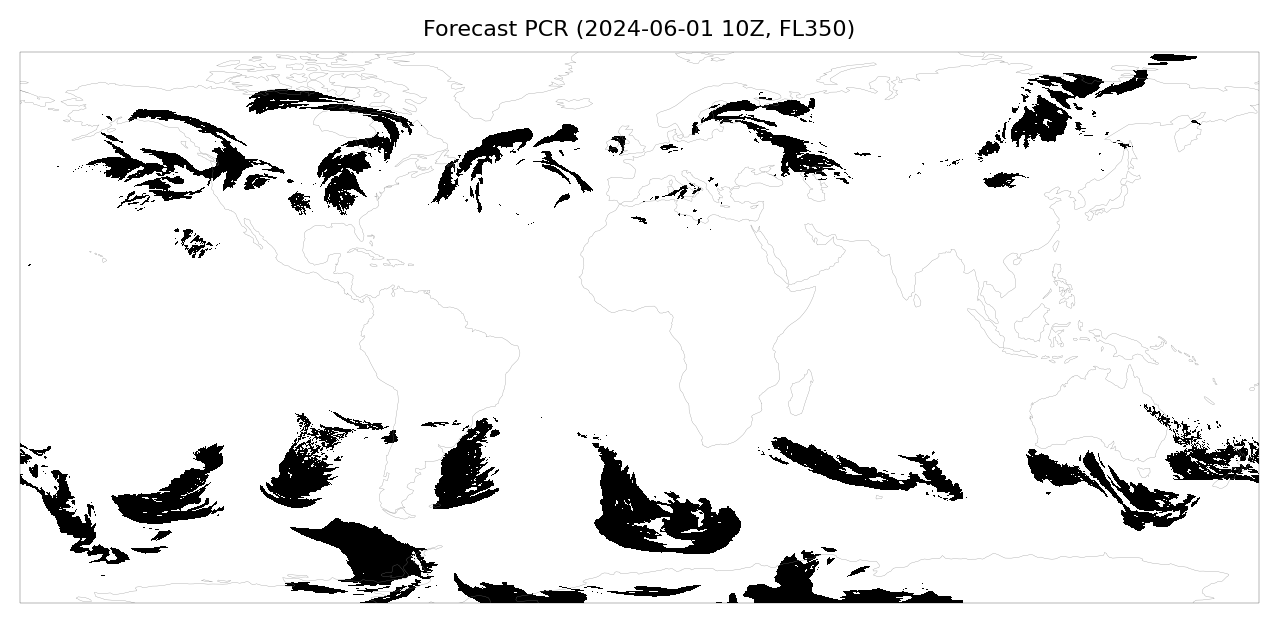

In [6]:
plt.figure(figsize=(6.5, 3), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, cmap="Greys", shading="nearest")
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"Forecast PCR ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# ADSB data

I wanted to use our ADSB API for this step, but it doesn't cover the time period (mid-2024) that we're planning to use initially. I'm using Roger's merged Spire/Aireon data instead--we should consider whether this is the right data source, given that we're restricted on how we can share it.

In [7]:
preprocess_adsb(time)

In [8]:
adsb = open_adsb(time, flight_level)

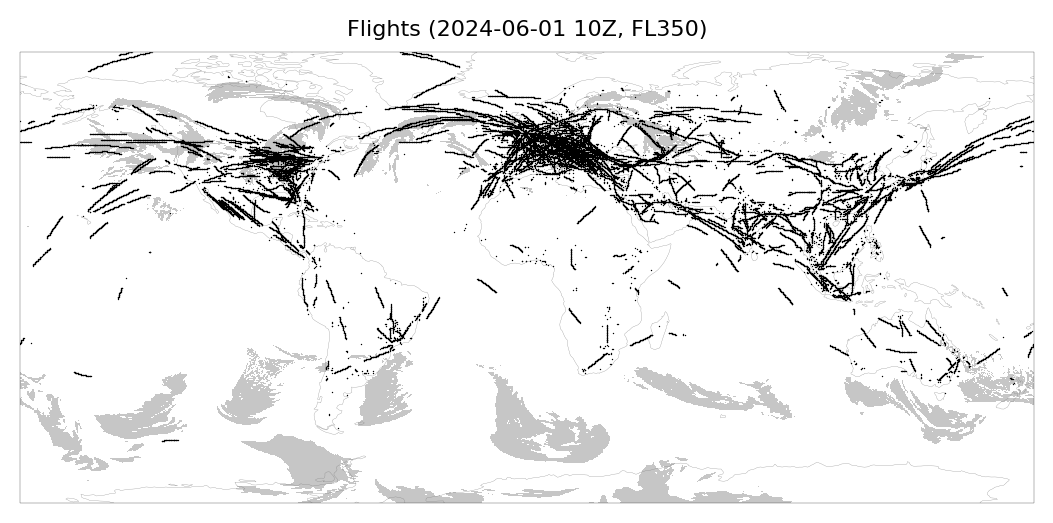

In [9]:
plt.figure(figsize=(6.5, 2.5), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, vmax=3, cmap="Greys", shading="nearest")
ax.plot(adsb["longitude"], adsb["latitude"], "k.", mew=0, ms=1)
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"Flights ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# IAGOS data

2024 IAGOS data isn't available through the public API yet, so I'm using some provisional data that Roger processed himself. Again, worth considering whether there's a better place we could get this.

In [10]:
preprocess_iagos(time)

In [11]:
iagos = open_iagos(time, flight_level)

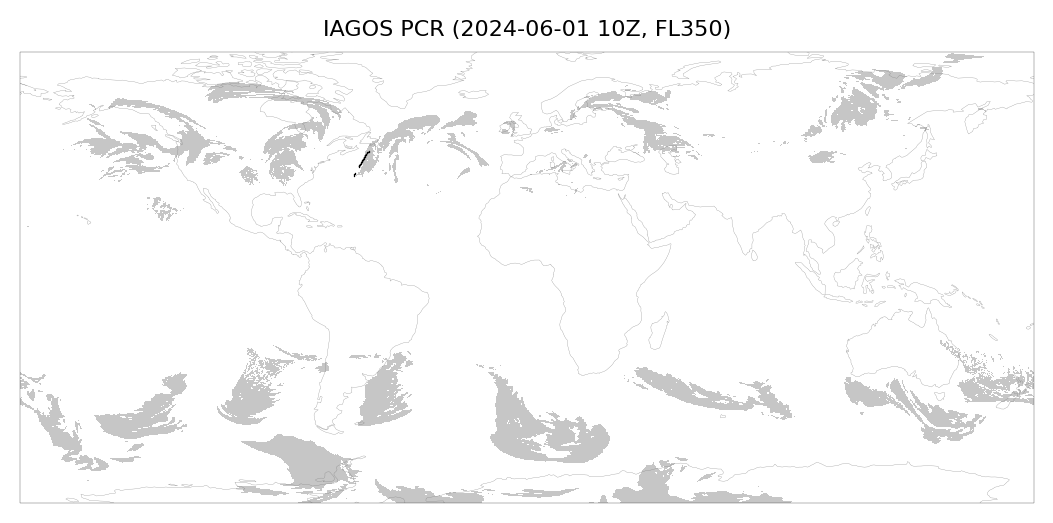

In [12]:
plt.figure(figsize=(6.5, 2.5), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, vmax=3, cmap="Greys", shading="nearest")
ax.plot(iagos["longitude"], iagos["latitude"], "k.", mew=0, ms=1)
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"IAGOS PCR ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Horizontal buffering

In [13]:
buffered = apply_horizontal_buffer(forecast["pcr"], 10)

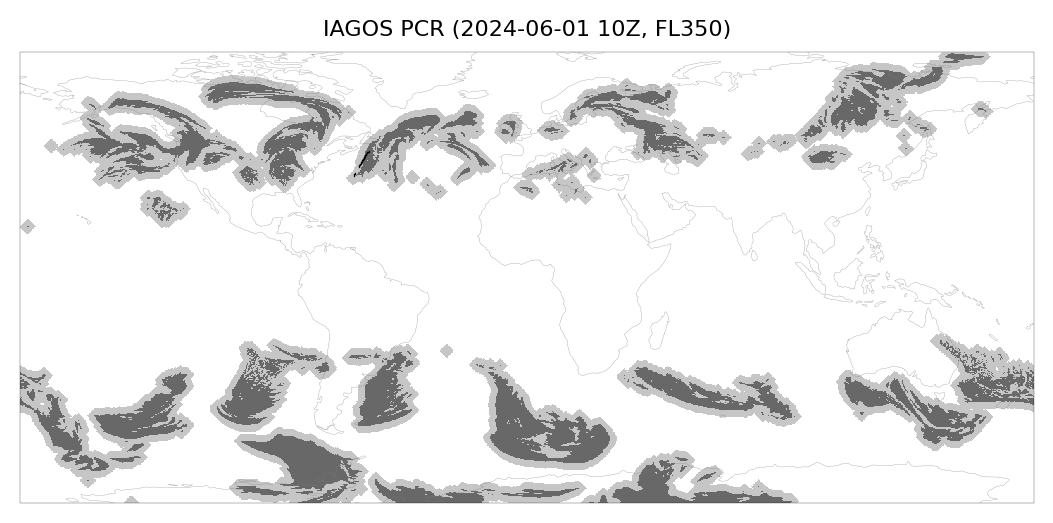

In [14]:
plt.figure(figsize=(6.5, 2.5), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], (forecast["pcr"].astype(int) + buffered.astype(int)).squeeze().T, vmax=3, cmap="Greys", shading="nearest")
ax.plot(iagos["longitude"], iagos["latitude"], "k.", mew=0, ms=1)
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"IAGOS PCR ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Hit rate calculation

In [15]:
calculate_pcr_area(forecast["pcr"], iagos)

(11226173253.728163, 23719148049.413372)

In [16]:
calculate_pcr_area(buffered, iagos)

(23719148049.413372, 23719148049.413372)

# Flight distance penalty

In [17]:
calculate_flight_distance(forecast["pcr"], adsb)

(307929540.39006656, 4071660307.5577774)

In [18]:
calculate_flight_distance(buffered, adsb)

(941010864.6033431, 4071660307.5577774)

# Sweep out curve

In [19]:
hit_rate = np.zeros((6,))
dist_frac = np.zeros((6,))
for i in range(6):
    buffered = apply_horizontal_buffer(forecast["pcr"], i)
    area, tot_area = calculate_pcr_area(buffered, iagos)
    hit_rate[i] = area / tot_area
    dist, tot_dist = calculate_flight_distance(buffered, adsb)
    dist_frac[i] = dist / tot_dist

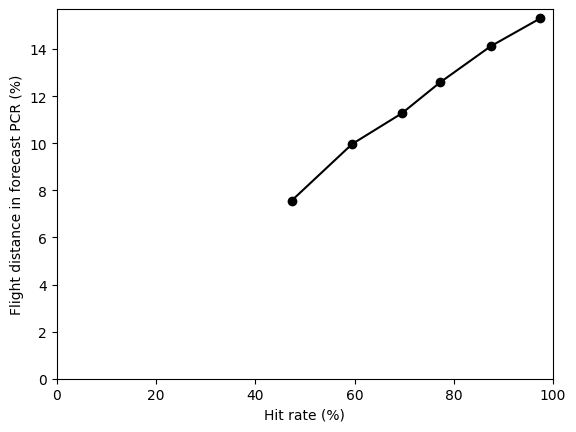

In [20]:
plt.plot(100 * hit_rate, 100 * dist_frac, "k-o")
plt.xlabel("Hit rate (%)")
plt.ylabel("Flight distance in forecast PCR (%)")
plt.ylim([0, None])
plt.xlim([0, 100]);

# Analyze staged results

In [2]:
! gcloud storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos .

Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010100.pq to file://./contrails-org-iagos/2024010100.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010101.pq to file://./contrails-org-iagos/2024010101.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010102.pq to file://./contrails-org-iagos/2024010102.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010103.pq to file://./contrails-org-iagos/2024010103.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010104.pq to file://./contrails-org-iagos/2024010104.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010105.pq to file://./contrails-org-iagos/2024010105.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024010106.pq to file://./contrails-org-iagos/2024010106.pq
Copying gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos/2024

In [2]:
df = dd.read_parquet("contrails-org-iagos/*.pq")

In [3]:
df = df[(df["vertical_buffer_up"] == 0) & (df["vertical_buffer_down"] == 0)]

In [5]:
hit_rate = df.groupby("horizontal_buffer")[["iagos_pcr_area_in_forecast_pcr", "iagos_pcr_area"]].apply(
    lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
    meta=("hit_rate", "f8")
).compute().sort_index()

In [6]:
dist_frac = df.groupby("horizontal_buffer")[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
    lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum(),
    meta=("distance_fraction", "f8")
).compute().sort_index()

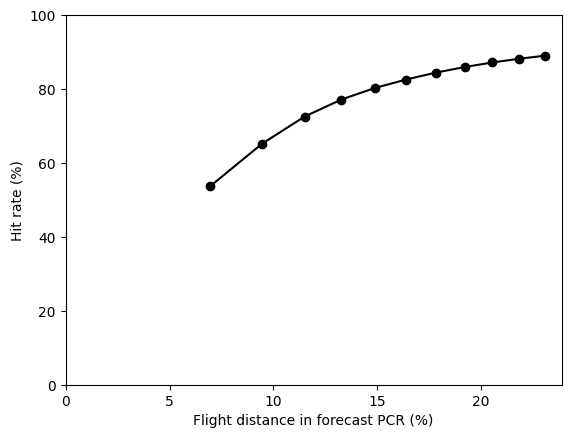

In [13]:
plt.plot(100 * dist_frac, 100 * hit_rate, "k-o")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, None])
plt.ylim([0, 100]);

In [5]:
df = df[df["horizontal_buffer"] == 0]

In [29]:
pcr = df.groupby([df["time"].dt.month, "flight_level"])[["iagos_pcr_area"]].apply(
    lambda x: x["iagos_pcr_area"].mean(),
    meta=("distance_fraction", "f8")
).compute().sort_index()

In [30]:
arr = pcr.to_numpy().reshape((9, -1))
month = range(1, 10)
flight_level = range(270, 450, 10)

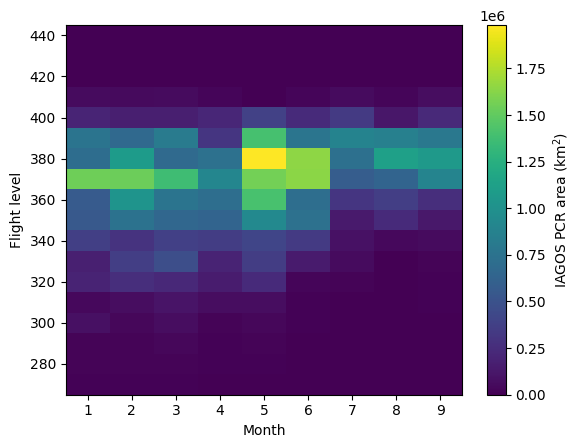

In [31]:
plt.pcolormesh(month, flight_level, arr.T / 1e3)
plt.colorbar(label="IAGOS PCR area (km$^2$)")
plt.xlabel("Month")
plt.ylabel("Flight level");

In [7]:
hit_rate = df.groupby([df["time"].dt.month, "flight_level"])[["iagos_pcr_area_in_forecast_pcr", "iagos_pcr_area"]].apply(
    lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
    meta=("hit_rate", "f8")
).compute().sort_index()

/tmp/ipykernel_478464/631832734.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
/tmp/ipykernel_478464/631832734.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
/tmp/ipykernel_478464/631832734.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
/tmp/ipykernel_478464/631832734.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
/tmp/ipykernel_478464/631832734.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
/tmp/ipykernel_478464/631832734.py:2: RuntimeWarning: invalid value encountered in scalar divide
  l

In [12]:
arr = hit_rate.to_numpy().reshape((9, -1))
month = range(1, 10)
flight_level = range(270, 450, 10)

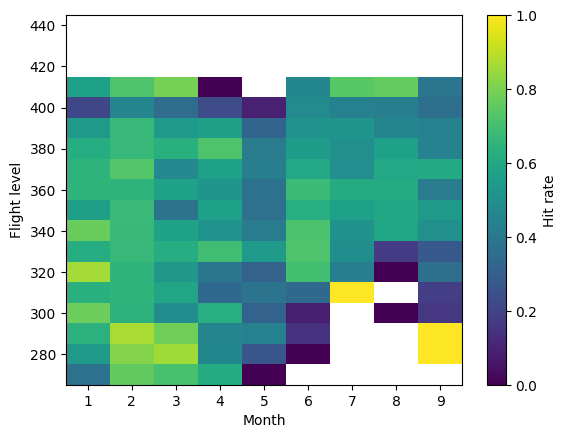

In [16]:
plt.pcolormesh(month, flight_level, arr.T)
plt.colorbar(label="Hit rate")
plt.xlabel("Month")
plt.ylabel("Flight level");

In [21]:
dist = df.groupby([df["time"].dt.month, "flight_level"])[["adsb_dist"]].apply(
    lambda x: x["adsb_dist"].sum(),
    meta=("flight_distance", "f8")
).compute().sort_index()

In [22]:
arr = dist.to_numpy().reshape((9, -1))
month = range(1, 10)
flight_level = range(270, 450, 10)

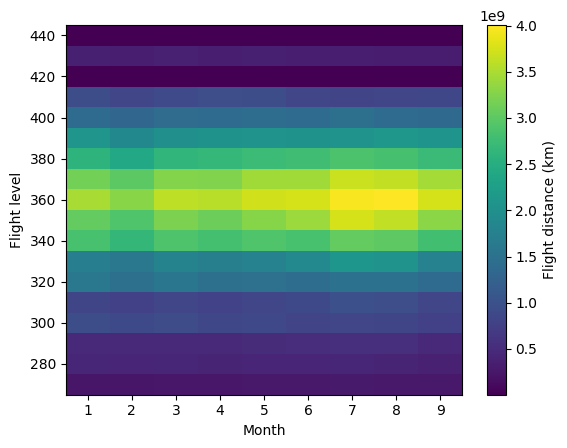

In [23]:
plt.pcolormesh(month, flight_level, arr.T / 1e3)
plt.colorbar(label="Flight distance (km)")
plt.xlabel("Month")
plt.ylabel("Flight level");

In [17]:
dist_frac = df.groupby([df["time"].dt.month, "flight_level"])[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
    lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum(),
    meta=("distance_fraction", "f8")
).compute().sort_index()

In [18]:
arr = dist_frac.to_numpy().reshape((9, -1))
month = range(1, 10)
flight_level = range(270, 450, 10)

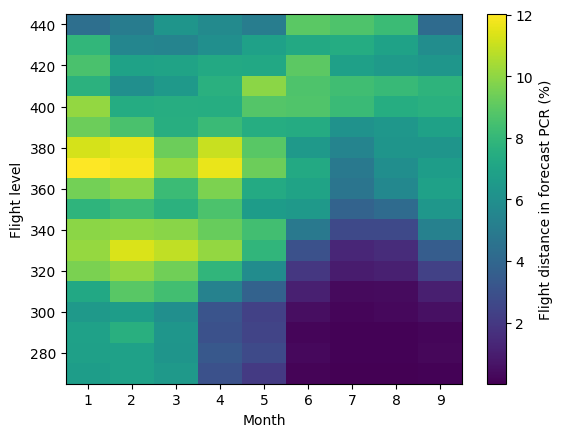

In [20]:
plt.pcolormesh(month, flight_level, 100 * arr.T)
plt.colorbar(label="Flight distance in forecast PCR (%)")
plt.xlabel("Month")
plt.ylabel("Flight level");

In [32]:
df = dd.read_parquet("contrails-org-iagos/*.pq")

In [33]:
df = df[(df["vertical_buffer_up"] == 0) & (df["vertical_buffer_down"] == 0)]

In [35]:
df = df[~df["time"].dt.month.isin((5, 6))]

In [36]:
hit_rate = df.groupby("horizontal_buffer")[["iagos_pcr_area_in_forecast_pcr", "iagos_pcr_area"]].apply(
    lambda x: x["iagos_pcr_area_in_forecast_pcr"].sum() / x["iagos_pcr_area"].sum(),
    meta=("hit_rate", "f8")
).compute().sort_index()

In [37]:
dist_frac = df.groupby("horizontal_buffer")[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
    lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum(),
    meta=("distance_fraction", "f8")
).compute().sort_index()

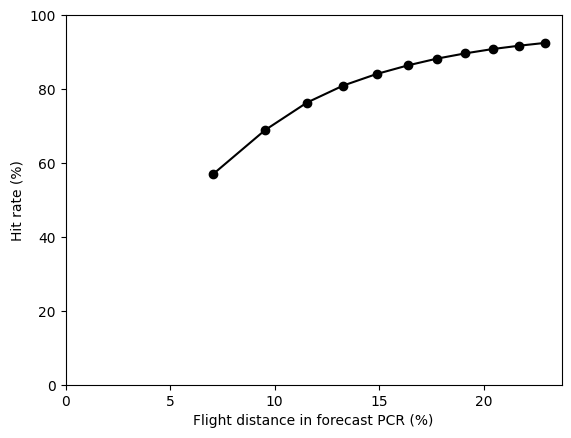

In [38]:
plt.plot(100 * dist_frac, 100 * hit_rate, "k-o")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, None])
plt.ylim([0, 100]);